# Neural Network with One Hidden Layer (from Scratch)

## Objective

Build a neural network with one hidden layer from scratch using NumPy for binary image classification.

## Topics

- Data preprocessing
- Parameter initialization
- Forward propagation
- Sigmoid activation
- Binary cross-entropy loss
- Backpropagation
- Gradient descent optimization
- Prediction
- Model evaluation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

from sklearn.metrics import accuracy_score, log_loss
from tqdm import tqdm
sys.path.append(os.path.abspath(".."))
from utilities.utilities import *

In [11]:
def initialize_parameters(n0, n1, n2):
    
    W1 = np.random.randn(n1, n0) * 0.01
    W2 = np.random.randn(n2, n1) * 0.01
    b1 = np.zeros((n1, 1))
    b2 = np.zeros((n2, 1))   
    parameters = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }

    return parameters

In [10]:
def preprocess(X):
    X = X.reshape(X.shape[0], -1)
    X = X/255.0
    return X

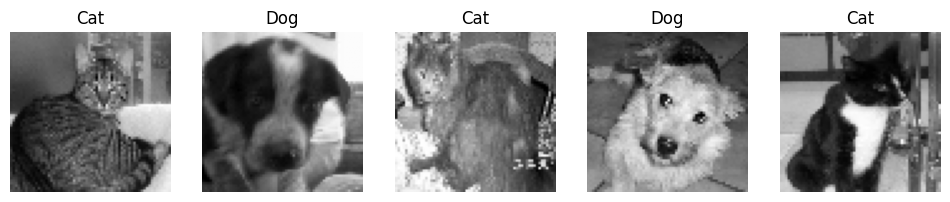

In [19]:
X_train, y_train, X_test, y_test = load_data()
indices = np.random.choice(len(X_train), size=5, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[idx], cmap="gray")  
    plt.title("Dog" if y_train[idx] == 1 else "Cat")  
    plt.axis("off")
plt.show()
X_train = preprocess(X_train).T           
X_test = preprocess(X_test).T     

In [20]:
def forward_propagation(X, parameters):
    W1, b1, W2, b2 = parameters['W1'], parameters['b1'], parameters['W2'], parameters['b2']
    Z1 = np.dot(W1, X) + b1      
    A1 = 1 / (1 + np.exp(-Z1)) 
    # A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2      
    A2 = 1 / (1 + np.exp(-Z2)) 

    activations = {
        'A1': A1,
        'A2': A2
    }

    return activations

In [21]:
def update_gradients(gradients, parameters, learning_rate):

    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']

    dW1 = gradients['dW1']
    db1 = gradients['db1']
    dW2 = gradients['dW2']
    db2 = gradients['db2']

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    parameters = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }

    return parameters

In [22]:
def back_propagation(X, y, parameters, activations):

    A1 = activations['A1']
    A2 = activations['A2']
    W2 = parameters['W2']

    m = y.shape[1]
    dZ2 = A2 - y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims = True)

    dZ1 = np.dot(W2.T, dZ2) * A1 * (1 - A1)
    # dZ1 = np.dot(W2.T, dZ2) * (1 - A1**2)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims = True)

    gradients = {
        'dW1' : dW1,
        'db1' : db1,
        'dW2' : dW2,
        'db2' : db2
    }
    
    return gradients

In [23]:
def predict(X, parameters):
  activations = forward_propagation(X, parameters)
  A2 = activations['A2']
  return A2 >= 0.5

In [37]:
def neural_network_one_hidden_layer(X_train, y_train, X_test, y_test, n1=32, learning_rate=0.01, n_iter=2000):

    n0 = X_train.shape[0]
    n2 = y_train.shape[1] 
    np.random.seed(0)
    parameters = initialize_parameters(n0, n1, n2)

    y_train = y_train.reshape(1, -1)
    y_test  = y_test.reshape(1, -1)

    train_loss, train_acc = [], []
    test_loss, test_acc = [], []

    # gradient descent
    for i in tqdm(range(n_iter)):
        # forward train
        activations_train = forward_propagation(X_train, parameters)
        A2_train = activations_train['A2']

        # forward test
        activations_test = forward_propagation(X_test, parameters)
        A2_test = activations_test['A2']

        # loss
        train_loss.append(log_loss(y_train.flatten(), A2_train.flatten()))
        test_loss.append(log_loss(y_test.flatten(), A2_test.flatten()))

        # accuracy
        y_pred_train = predict(X_train, parameters)
        y_pred_test  = predict(X_test, parameters)

        train_acc.append(accuracy_score(y_train.flatten(), y_pred_train.flatten()))
        test_acc.append(accuracy_score(y_test.flatten(), y_pred_test.flatten()))

        # backpropagation + update
        gradients = back_propagation(X_train, y_train, parameters, activations_train)
        parameters = update_gradients(gradients, parameters, learning_rate)
        
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='train loss')
    plt.plot(test_loss, label='test loss')
    plt.legend()
    plt.title("Loss")

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='train accuracy')
    plt.plot(test_acc, label='test accuracy')
    plt.legend()
    plt.title("Accuracy")
    plt.show()
    
    print("Train Accuracy :", np.max(train_acc))
    print("Test Accuracy  :", np.max(test_acc))
    print("\n")
    
    return parameters


100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:38<00:00, 51.30it/s]


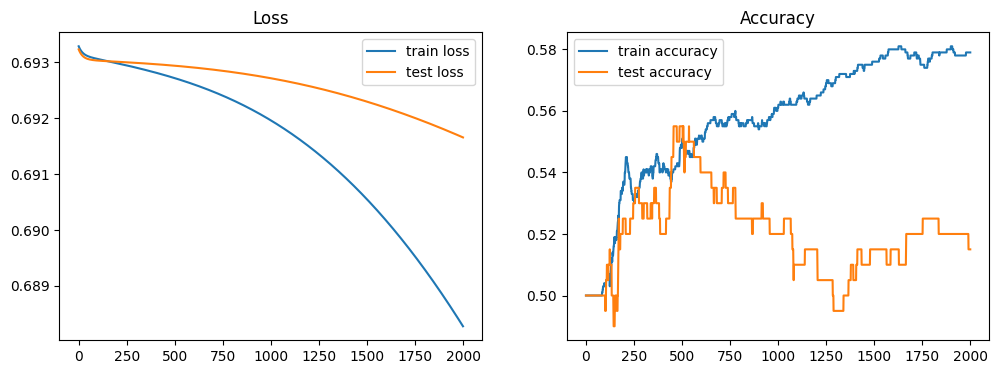

Train Accuracy : 0.581
Test Accuracy  : 0.555




In [38]:
parameters = neural_network_one_hidden_layer(X_train, y_train, X_test, y_test)
y_pred = predict(X_test, parameters)


A neural network with one hidden layer was successfully implemented from scratch using NumPy, achieving **58.1% training accuracy** and **55.5% test accuracy**. Although the hidden layer introduces non-linearity, the model remains relatively simple. In the next notebook, the network will be extended to multiple hidden layers to explore deeper architectures.